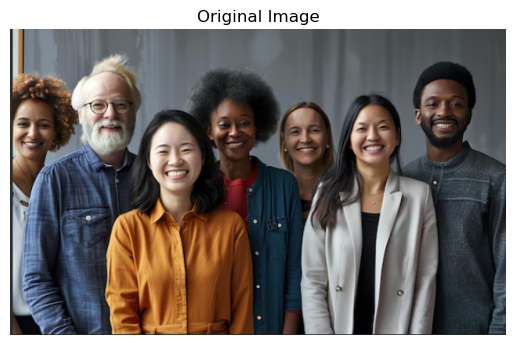

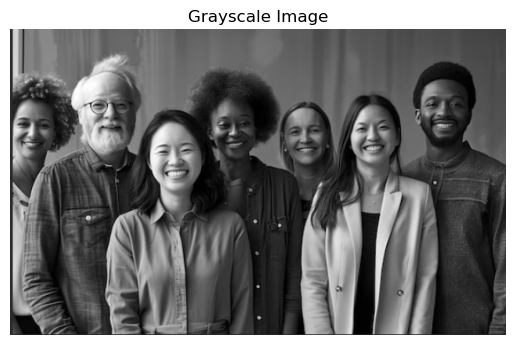

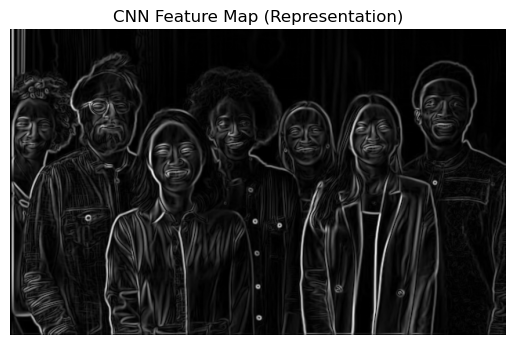

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\anaconda\envs\61782323110047\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\anaconda\envs\61782323110047\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "D:\anaconda\envs\61782323110047\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


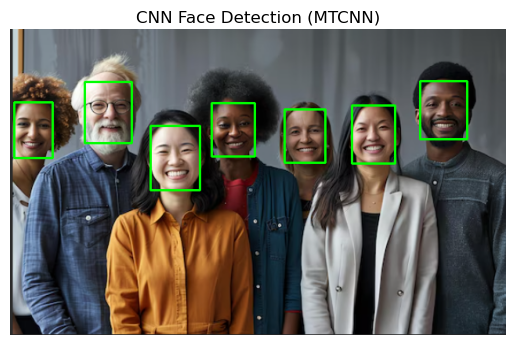

Number of faces detected: 7


In [6]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN

image_path = r"C:\Users\Janane S B\Downloads\input.jpg.png"   # <-- change this to your file path

img = cv2.imread(image_path)
if img is None:
    print("Error: Image not found. Check path!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.show()
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

    feature_map = cv2.magnitude(sobelx, sobely)
    feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())

    plt.imshow(feature_map, cmap='gray')
    plt.title("CNN Feature Map (Representation)")
    plt.axis("off")
    plt.show()
    detector = MTCNN()
    faces = detector.detect_faces(img_rgb)

    output = img_rgb.copy()

    for face in faces:
        x, y, width, height = face['box']
        cv2.rectangle(output, (x, y), (x + width, y + height), (0, 255, 0), 2)
    plt.imshow(output)
    plt.title("CNN Face Detection (MTCNN)")
    plt.axis("off")
    plt.show()

    print("Number of faces detected:", len(faces))